Name: Malaika
REGNO:23-NTU-CS-1291
LAB2
BS-A1-5th

Linear Regression Model

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

In [8]:
#Dataset Loading
data=pd.read_csv("Admission_Predict.csv")
df=pd.DataFrame(data)
print(df)

     Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0             1        337          118                  4  4.5   4.5  9.65   
1             2        324          107                  4  4.0   4.5  8.87   
2             3        316          104                  3  3.0   3.5  8.00   
3             4        322          110                  3  3.5   2.5  8.67   
4             5        314          103                  2  2.0   3.0  8.21   
..          ...        ...          ...                ...  ...   ...   ...   
495         496        332          108                  5  4.5   4.0  9.02   
496         497        337          117                  5  5.0   5.0  9.87   
497         498        330          120                  5  4.5   5.0  9.56   
498         499        312          103                  4  4.0   5.0  8.43   
499         500        327          113                  4  4.5   4.5  9.04   

     Research  Chance of Admit   
0           1    

In [9]:
#Columns names
columns=df.columns
print(columns)

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')


In [10]:
#Basic EDA
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [26]:
#Feaure Selection
X=df.drop('Chance of Admit ',axis=1)
y=df['Chance of Admit ']
#Feature Scaling
scaler=StandardScaler()
scaler.fit_transform(X)
#Train-Test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [30]:
model=LinearRegression()
model.fit(X_train,y_train)
Predict=model.predict(X_test)
#RMSE
rms=np.sqrt(metrics.mean_squared_error(y_test,Predict))
print(rms)




0.06002754086512893


In [31]:
r2=np.sqrt(metrics.r2_score(y_test,Predict))
print(r2)

0.9115087008647464


In [43]:
new_data = {
    "GRE Score": [320],
    "TOEFL Score": [110],
    "University Rating": [4],
    "SOP": [4.0],
    'LOR ': [4.5],
    "CGPA": [8.9],
    "Research": [1]
}

new_df = pd.DataFrame(new_data)

# Predict on new data
predicted = model.predict(new_df)[0]
print("Predicted Chance of Admit:", round(predicted, 3))

Predicted Chance of Admit: 0.81



Ln

Linear Regression From Scratch

In [2]:
#Loading Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#Dataset loading
data=pd.read_csv("headbrain.csv")
df=pd.DataFrame(data)
print("Data Loaded successfully")
print(df)

Data Loaded successfully
     Gender  Age Range  Head Size(cm^3)  Brain Weight(grams)
0         1          1             4512                 1530
1         1          1             3738                 1297
2         1          1             4261                 1335
3         1          1             3777                 1282
4         1          1             4177                 1590
..      ...        ...              ...                  ...
232       2          2             3214                 1110
233       2          2             3394                 1215
234       2          2             3233                 1104
235       2          2             3352                 1170
236       2          2             3391                 1120

[237 rows x 4 columns]


In [3]:
#Check missing values
df.isnull().sum()

Gender                 0
Age Range              0
Head Size(cm^3)        0
Brain Weight(grams)    0
dtype: int64

In [5]:
#Feature Selection
X=df["Head Size(cm^3)"].values
y=df["Brain Weight(grams)"].values

In [7]:
#Total number of X
N=len(X)
print("Total no of Values are:",N)

Total no of Values are: 237


In [9]:
#Calculate Parameters
SumofX=np.sum(X)
Sumofy=np.sum(y)
Xsquare=np.sum(X*X)
SumofXy=np.sum(X*y)
print("Sum Of X is:",SumofX)
print("Sum of X^2 is:",Xsquare)
print("Sum of y is:",Sumofy)
print("Sum of Xy is:",SumofXy)

Sum Of X is: 861256
Sum of X^2 is: 3161283190
Sum of y is: 304041
Sum of Xy is: 1113176805


In [26]:
#Estimate Parameters
num=N*np.sum(X*y)-np.sum(X)*np.sum(y)
den=N*np.sum(X*X)-(np.sum(X))**2
w1=num/den
print("Value of w1 is:",w1)

Value of w1 is: 0.2634293394893993


In [27]:
w0=(np.sum(y)-w1*(np.sum(X)))/N
print("Value of w1 is:",w0)

Value of w1 is: 325.57342104944274


In [28]:
Xmax=np.max(X)
Xmin=np.min(X)
print("Max Value of X is:",Xmax)
print("Minimum Value of X is:",Xmin)


Max Value of X is: 4747
Minimum Value of X is: 2720


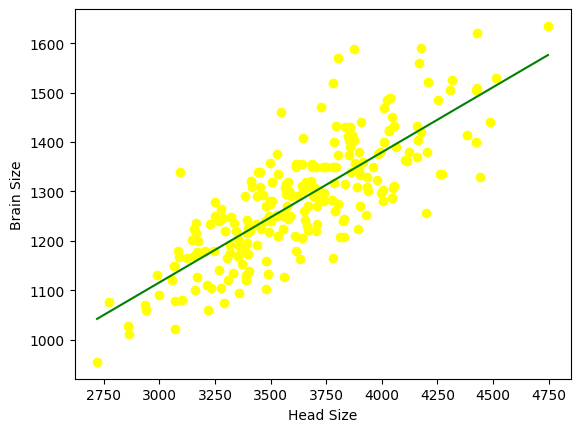

In [29]:
#Plotting 
x1=np.linspace(Xmin,Xmax)
y1=w0+w1*x1
#Scatter Plot
plt.plot(x1,y1,label="Regression Line",color='green')
plt.scatter(X,y,label="Scatter Plot",color='yellow')
plt.xlabel("Head Size")
plt.ylabel("Brain Size")
plt.show()


In [32]:
#Calculate RMSE
rmse=0
for i in range(N):
    ypred=w0+w1*X[i]
    rmse+=(y[i]-ypred)**2
rmse=np.sqrt(rmse/N)
print("Root Mean Squared Error is:",rmse)

Root Mean Squared Error is: 72.12062137837088


In [33]:
#Calculate R square
SS_tot=0
SS_res=0
mean=np.mean(y)
for i in range(N):
    ypred=w0+w1*X[i]
    SS_tot+=(y[i]-mean)**2
    SS_res+=(y[i]-ypred)**2
r2=1-(SS_res/SS_tot)
print("Root  Squared Error is:",r2)

Root  Squared Error is: 0.6393117199570004


MultiVariant Linear Regression


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [42]:
#Data Loading
data=pd.read_csv("1000_Companies.csv")
df=pd.DataFrame(data)
print("DataSet Loaded Successfully")
print(df)

DataSet Loaded Successfully
     R&D Spend  Administration  Marketing Spend       State        Profit
0    165349.20      136897.800      471784.1000    New York  192261.83000
1    162597.70      151377.590      443898.5300  California  191792.06000
2    153441.51      101145.550      407934.5400     Florida  191050.39000
3    144372.41      118671.850      383199.6200    New York  182901.99000
4    142107.34       91391.770      366168.4200     Florida  166187.94000
..         ...             ...              ...         ...           ...
995   54135.00      118451.999      173232.6695  California   95279.96251
996  134970.00      130390.080      329204.0228  California  164336.60550
997  100275.47      241926.310      227142.8200  California  413956.48000
998  128456.23      321652.140      281692.3200  California  333962.19000
999  161181.72      270939.860      295442.1700    New York  476485.43000

[1000 rows x 5 columns]


In [43]:
print("Columns in dataset are:")
columns=df.columns
print(columns)

Columns in dataset are:
Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')


In [44]:
#Checking missing values
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [45]:
#Feature Selection
X=df.iloc[:,:-1].values
y=df.iloc[:,4].values
X[:5]

array([[165349.2, 136897.8, 471784.1, 'New York'],
       [162597.7, 151377.59, 443898.53, 'California'],
       [153441.51, 101145.55, 407934.54, 'Florida'],
       [144372.41, 118671.85, 383199.62, 'New York'],
       [142107.34, 91391.77, 366168.42, 'Florida']], dtype=object)

<Axes: >

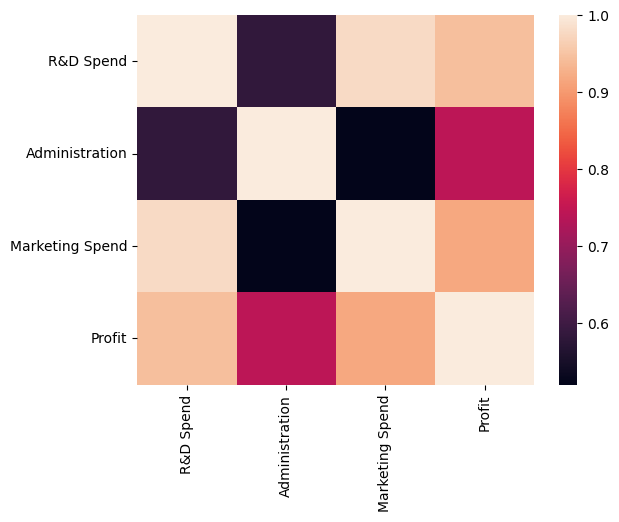

In [46]:
#Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True))

In [62]:
#Label Encding
e=LabelEncoder()
X[:,3]=e.fit_transform(X[:,3])
X[:5]





array([[165349.2, 136897.8, 471784.1, 2],
       [162597.7, 151377.59, 443898.53, 0],
       [153441.51, 101145.55, 407934.54, 1],
       [144372.41, 118671.85, 383199.62, 2],
       [142107.34, 91391.77, 366168.42, 1]], dtype=object)

In [63]:
#Train-test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [64]:
#Model Training
model=LinearRegression()
model.fit(X_train,y_train)
pred=model.predict(X_test)

In [65]:
#calculted predicted and actual value
print("Predicted values is:",pred[:5])
print("Actual Value is:",y_test[:5])

Predicted values is: [ 89624.88499984  88261.44060358  94728.57723845 176034.49990954
  83234.84214495]
Actual Value is: [ 89012.02672  87654.55773  94093.35179 175396.2616   83356.61784]


In [66]:
#RMSE
rmse=metrics.mean_squared_error(y_test,pred)
print("Root mean squared error is:",rmse)

Root mean squared error is: 192169702.49522415


In [67]:
r2=metrics.r2_score(y_test,pred)
print("R square is:",r2)

R square is: 0.9112595959622045


In [69]:
#Predict profit on new data
# Order: R&D Spend, Administration, Marketing Spend, State
new_data = [[165349.20, 136897.80, 471784.10, 2]]

predicted_profit = model.predict(new_data)
print("Predicted Profit:", predicted_profit[0])


Predicted Profit: 201298.87175033888
